# Incorporating a desperation threshold into decision-making under uncertainty

To embed a threshold or inflection point, we can add a modified softmax decision-making equation. The softmax equation is defined as:

$$
Pr(c ∈C)=\frac{e^{V_c }}{\sum_{c=1}^C e^{V_c} }
$$

Where $e^{V_s}$ is the exponentiated expected value of a choice c, and $ ∑_{c=1}^{C}e^{V_c} $ is the sum of the exponentiated expected value of all choices. The softmax equation returns the probability of making a choice that is proportional to the choice’s expected value. In psychology, we use the softmax to represent the mechanism in which a person makes a choice. Importantly, it does not represent a specific psychological process but acknowledges that people’s choices are not deterministic. 

To embed an inflection point or threshold, we can introduce a threshold parameter $\tau$ and modify the logits with this threshold. To create a U-shaped softmax function with an inflection point at 0, we can use a quadratic function centered at the inflection point.

If the amount of wealth  (or the number of resources) is negative, we add a scaling factor $\tau$, which controls the steepness of the U-shape:

$$
Pr(c ∈ C)=\frac{e^{V_c }}{∑_{c=1}^Ce^{-τV_c } }
$$

We can choose a value of $\tau$ and keep it fixed, or we can have it be proportional to the amount of wealth one has, such that more debt makes the person even more inclined to uncertain and rule-breaking behaviors.

The $\tau$ parameter represents one’s desperation, but not necessarily an agent’s psychological preference or attitude toward risk. In other words, a person can be ambiguity averse, as represented in the beta and alpha coefficients of the decision-making model but will embrace uncertain decisions when their resources fall below a threshold. This notion of desperation corresponds to several scenarios, such as running into a burning building to save a loved one (you still feel afraid and risk averse, yet do it anyways out of an urge to keep your loved one safe) or committing a crime (i.e., you are averse to the risk and its potential consequences, yet, you feel trapped and that this is the only option).


## Demonstration of desperation threshold

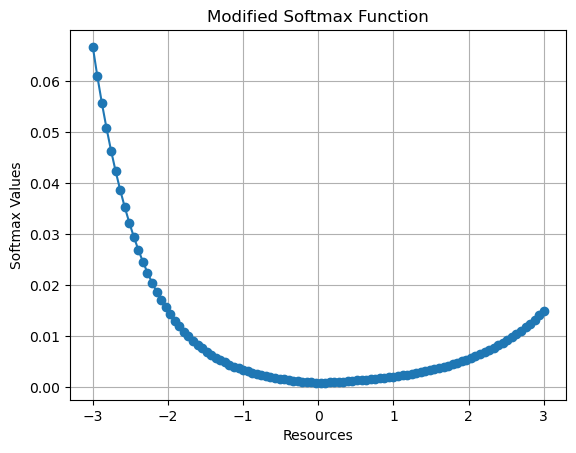

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Modified U-shaped softmax function
def u_shaped_softmax(logits, tau):
    modified_logits = np.where(logits < 0, -tau * logits, logits)
    return np.exp(modified_logits) / np.sum(np.exp(modified_logits))


# Input logits
logits_u_shape = np.linspace(-3, 3, 100)

# Parameter (scaling factor)
tau = 1.5

# Compute U-shaped softmax
u_shaped_softmax_values = u_shaped_softmax(logits=logits_u_shape, tau=tau)

# Plotting the U-shaped softmax function
plt.plot(logits_u_shape, u_shaped_softmax_values, marker='o')
plt.title('Modified Softmax Function')
plt.xlabel('Resources')
plt.ylabel('Softmax Values')
plt.grid()

## Incorporating desperation threshold into decision-making model simulation

TO DO: Incorporate cognitive variables into this simulation!

Here's what the desperation threshold looks like when the decision-making model is embedded within the softmax function:

<Figure size 1000x500 with 0 Axes>

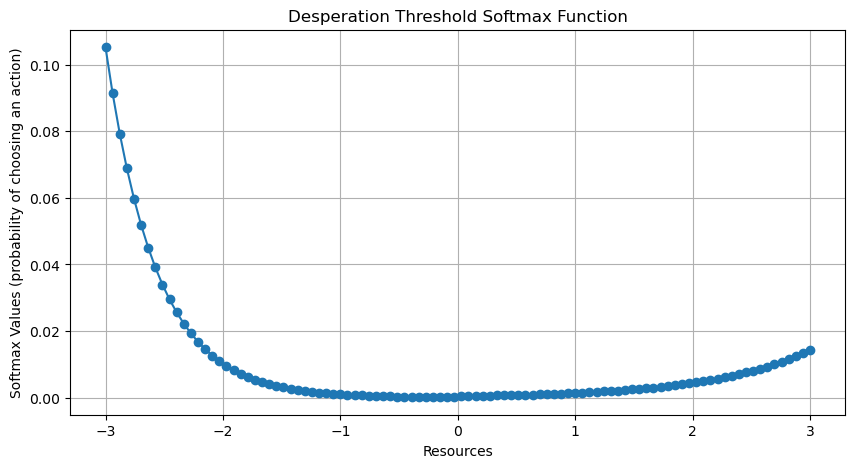

<Figure size 1000x500 with 0 Axes>

In [40]:
# Desperation threshold softmax function
def desperation_softmax(resources, logits, tau):
    modified_logits = np.where(resources < 0, -tau * logits, logits)
    return np.exp(modified_logits) / np.sum(np.exp(modified_logits))

# Input logits
logits_list = np.linspace(-3, 4, 100)

# Input resources
resources = np.linspace(-3, 3, 100)

# Compute U-shaped softmax with resources
test_softmax_values = desperation_softmax(resources=resources, logits=logits_list, tau = 2)

# Plotting the softmax function with resources
plt.figure(figsize=(10, 5))
plt.plot(resources, test_softmax_values, marker='o')
plt.title('Desperation Threshold Softmax Function')
plt.xlabel('Resources')
plt.ylabel('Softmax Values (probability of choosing an action)')
plt.grid()
plt.figure(figsize=(10, 5))



In [ ]:
import cognitive_functions as cf


A=500, C=25, theta=50, p_ij=0.1, gammas = 0.5, beta_i=1.9, alpha_i=0.8

all_probs = u_shaped_softmax(logits=eu_list, tau=1.3)

